Question 6.1

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     126   (530, 530)   float32   
SIMPLE            = True
BITPIX            = -32
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
This data structure is a: <class 'numpy.ndarray'>
Its shape should be (NAXIS2, NAXIS1): True

May share memory: True
Min. and max. data values: 1507.0 15752.0
N=280900 min=1507.0, max=15752.0, mean=4795.923828125, std=1848.255910605736
3551.0 876
Mode of the data: 3551.0 with 876 counts
Median of the data: 4102.0


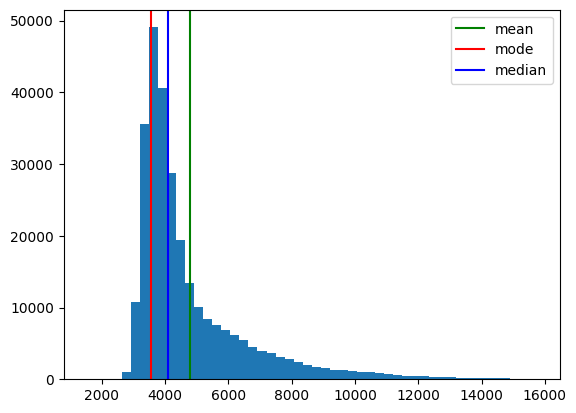

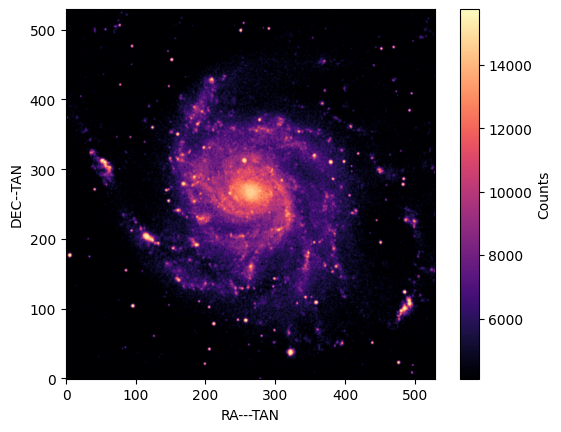

In [62]:
from astropy.io import fits
import numpy as np
from math import *
from matplotlib import pyplot as plt
from scipy import stats
from matplotlib.pyplot import figure, show


#opening the image and getting its info
hdulist = fits.open('m101.fits')
hdulist.info()

#questions
#How many HDU’s are in this FITS file? --> are 2 HDU's in this fits file?
#Which HDU contains the image data? What is the index of that HDU in the list? --> The first one, index [0]
#What is the number type of the data? --> primaryHDU is the containor type but the number type is int16
#The BITPIX = 16 Does it correspond with the data type found in the previous question? 
#16 corresponds to a 16-bit signed integer, which matches NumPy dtype int16


hdr = hdulist[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
    
dat = hdulist[0].data


hdr['BUNIT'] = 'Counts'

# Convert to float
dat_float = dat.astype(np.float32)


print("This data structure is a:", type(dat))
print("Its shape should be (NAXIS2, NAXIS1):", (hdr['NAXIS2'], hdr['NAXIS1']) == dat.shape)

print("\nMay share memory:", np.may_share_memory(dat,hdulist[0].data))
print("Min. and max. data values:", dat.min(), dat.max())

#questions
#What is the shape of the NumPy array dat.
#It shows that NAXIS2, NAXIS1 so the shape is (530, 530)
#Does this correspond to the information returned with info()?
#Yes it does that is why it says true
#Does it correspond to the values of the NAXIS keywords in the header?
#Yes it does with the values 530 for NAXIS1 and 530 for NAXIS2
#What is the contents of the attribute dtype of the array dat
#it is int16
#Check online for the meaning of dtype. Does it correspond to the value in BITPIX=?
#yes because there are 16 integers

flatdat = dat.flatten()
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(flatdat)
print(f"N={nobs} min={minval}, max={maxval}, mean={mean}, std={var**0.5}")

mode, counts = stats.mode(flatdat)
print(mode, counts)
print(f"Mode of the data: {mode} with {counts} counts")

median = np.median(dat.flat)
print(f"Median of the data: {median}")

fig, ax = plt.subplots()

ax.hist(flatdat, bins=50)
ax.axvline(mean, color='green', label='mean')
ax.axvline(mode, color='red', label='mode')
ax.axvline(median, color='blue', label='median')

ax.legend()
plt.show()

medd = np.median(np.asarray(dat))
fig, ax = plt.subplots()

img = ax.imshow(dat_float, origin="lower", vmin=medd, cmap='magma')
ax.set_xlabel(hdr['CTYPE1'])
ax.set_ylabel(hdr['CTYPE2'])

cbar = fig.colorbar(img, ax=ax)
cbar.set_label('Counts')   # <-- should match BUNIT

plt.show()

# Write new FITS file
datfloat = dat.astype(np.float32)
new_hdu = fits.PrimaryHDU(data=datfloat, header=hdr)
new_hdu.header = hdr    
new_hdu.writeto('m101_float.fits', overwrite=True, output_verify='ignore')
hdulist.close()

Question 6.3

9251.96048035226
the mean is: 9113.12 and the standard deviation is: 1596.8145150893388


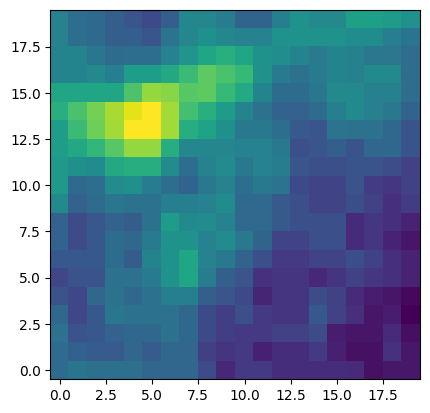

In [38]:
from astropy.io import fits
import numpy as np
from math import *
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure, show

#openin the file
hdul = fits.open("m101.fits")
datarray = hdul[0].data.astype('float64')
hdul.close()

#taking a slice, showing that
slicedat = datarray[200:220, 300:320]
plt.imshow(slicedat, origin = 'lower')

#flattening the vvalues so we can calculate with them
flatdat = slicedat.flatten()
flatdat2 = flatdat ** 2

#finding the RMS
Xrms = sqrt((np.sum(flatdat2)/len(flatdat2)))


#finding the mean and standard deviation
mean = np.mean(flatdat)
stdev = np.std(flatdat)

#printing them
print(Xrms)
print(f"the mean is: {mean} and the standard deviation is: {stdev}")

#The standard deviation is better for noise because the rms mixes signal and noise 

Question 6.5

The standard deviation for the first image is: 9.98401556679484
The standard deviation for the second image is: 10.003955116338458
The standard deviation for the third image is: 9.995349488722516
the standard deviation of the total map is: 5.773191380233297
The theoretical standard deviation of the total map is: 5.7667228164314235


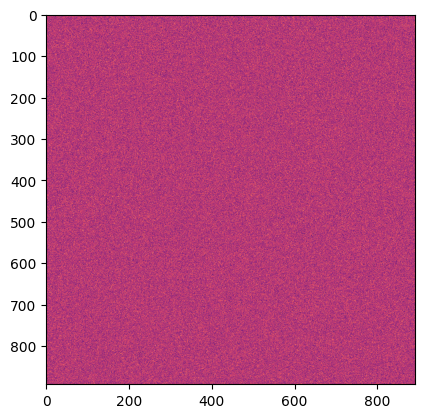

In [60]:
from astropy.io import fits
import numpy as np
from math import *
from matplotlib import pyplot as plt
from scipy import stats
from matplotlib.pyplot import figure, show


#Importing the imgaes
noisemap0 = fits.open('noisemap0.fits')
noisemap1 = fits.open('noisemap1.fits')
noisemap2 = fits.open('noisemap2.fits')

#getting the data from the fit files
dat0 = noisemap0[0].data
dat1 = noisemap1[0].data
dat2  = noisemap2[0].data

#calculating the standard deviation of the fits files
nm0stdev = np.std(dat0)
nm1stdev = np.std(dat1)
nm2stdev = np.std(dat2)

#printing the values
print(f"The standard deviation for the first image is: {nm0stdev}")
print(f"The standard deviation for the second image is: {nm1stdev}")
print(f"The standard deviation for the third image is: {nm2stdev}")

#creating a stack of the images and calculate the mean
stack = np.stack((dat0, dat1, dat2), axis=0)
tot = np.mean(stack, axis=0)
flattot = tot.flatten()

#plotting the stacked images and getting the standard deviation
plt.imshow(tot, cmap = 'magma')
totstdev = np.std(tot)
print(f"the standard deviation of the total map is: {totstdev}")

#calculating the standard deviation the theoretical way
stdev = (tot - np.mean(flattot))**2
stdev1 = sqrt(np.sum(stdev))/len(stdev)
print(f"The theoretical standard deviation of the total map is: {stdev1}")


Question 6.6

In [63]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data 
colnames = hdul[1].columns.names

t = Table(data)


mask = (
    (t['STARFLAG'] == 0) & 
    (t['ASPCAPFLAG'] == 0) & 
    (t['SNR'] > 10) & 
    (t['GAIAEDR3_PARALLAX'] / t['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(t['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

t['DATAFLAG'] = 0
t['DATAFLAG'][mask] = 1

m_G = t['GAIAEDR3_PHOT_G_MEAN_MAG']
pllx = t['GAIAEDR3_PARALLAX']

validpllx = pllx > 0

M = np.full(len(pllx), -1.0)
M[validpllx] = m_G[validpllx] - 5 * np.log10(pllx[validpllx]/1000) + 5

t['ABSOLUTE_MAG'] = np.where(t['DATAFLAG'] == 1, M, -1.0)

t.write('APOGEE_update.fits', format = 'fits', overwrite = True)

print(t)


GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG    ABSOLUTE_MAG  
----------------- ----------------------- ... -------- -----------------
              nan                     nan ...        0              -1.0
       0.28544167                0.019475 ...        0              -1.0
       0.08209286                0.315081 ...        0              -1.0
        1.2985312              0.00952245 ...        0              -1.0
        1.2985312              0.00952245 ...        1 31.65363883972168
      -0.02394128               0.0450072 ...        0              -1.0
        1.3863556               0.0175672 ...        1  31.5665283203125
              ...                     ... ...      ...               ...
         4.132398                0.015343 ...        0              -1.0
      0.057267956               0.0597211 ...        0              -1.0
        1.4367273               0.0213831 ...        0              -1.0
       0.42296618               0.0192445 ...      

Question 6.7

0        1.779496e+06
1        1.558734e+06
2        9.203894e+05
3        8.074825e+05
4        1.122358e+06
             ...     
32195    3.396710e+02
32196    3.696483e+01
32197    3.764135e+02
32198    1.515553e+02
32199    1.482101e+03
Name: phot_g_mean_flux, Length: 32200, dtype: float64
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
The value for m0 is: 25.68840037029544


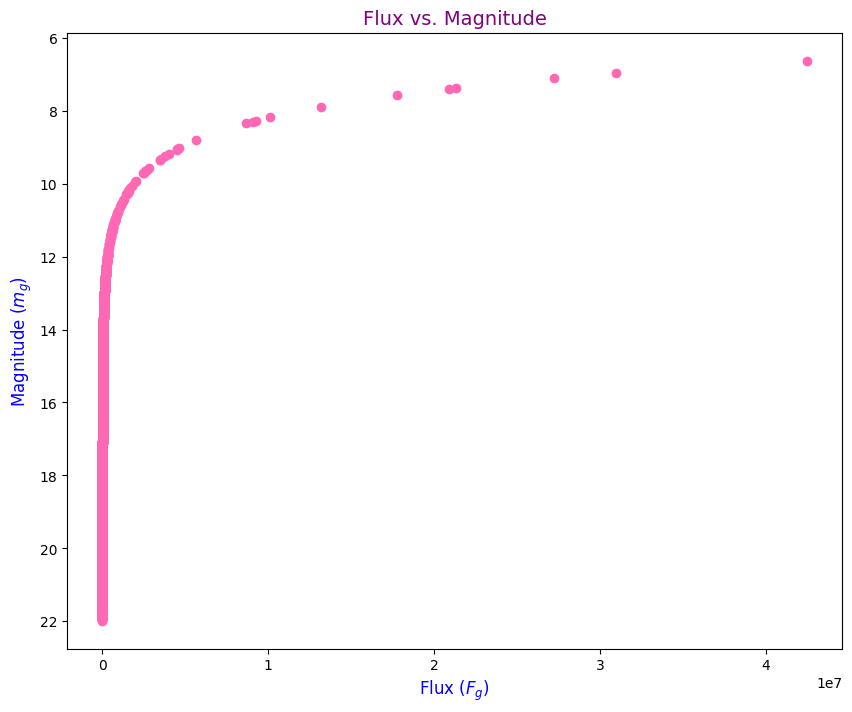

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#open the downloaded table
t = pd.read_csv('gaiaTestData.csv')

#getting the max value of the flux and then printing the corresponding row
maxGTD = t["phot_g_mean_flux"] == t["phot_g_mean_flux"].max()
print(t["phot_g_mean_flux"])
print(t[maxGTD])

#sorting the values in ascending order so we can plot them in a nice plot
t.sort_values(["phot_g_mean_flux"], ascending = True)

#setting up the plot
fig, ax = plt.subplots(figsize= (10,8))

#creating a scatter plot
ax.scatter(t["phot_g_mean_flux"], t["phot_g_mean_mag"], color = 'hotpink')

#making the plot look pleasing
ax.set_title('Flux vs. Magnitude', fontsize=14, color = 'purple')
ax.set_xlabel('Flux ($F_g$)', fontsize=12, color = 'blue')
ax.set_ylabel('Magnitude ($m_g$)', fontsize=12, color = 'blue')
ax.invert_yaxis()

#calculating the m0
mg = t["phot_g_mean_mag"]
Fg = t["phot_g_mean_flux"]
m0 = mg + 2.5 *np.log10(Fg)
print(f"The value for m0 is: {m0.mean()}")

Question 6.10

In [35]:
from astroquery.gaia import Gaia
import pandas as pd

#setting up the query that gives us the values we want later
Querry ="""
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error >5
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

#plugging the query into the gaia and then printing it
job = Gaia.launch_job(Querry)
t = job.get_results()
tp = t.to_pandas()
print(t)

#create a file
t.write("astroquery_gaia.fits", format = 'fits', overwrite = True)

     SOURCE_ID              ra         ... phot_bp_mean_mag phot_rp_mean_mag
                           deg         ...       mag              mag       
------------------- ------------------ ... ---------------- ----------------
4267180339403392768  286.7169128963743 ...        15.942071        14.419943
6709252873623174016     276.6911939192 ...        16.380306        15.151749
4040949706019490560 265.22936348434496 ...        16.118845        13.680644
4517539583701880064 284.02566215626837 ...        16.652264        15.347014
1823532754729083392 300.80580445460237 ...        14.782262        13.795675
3586362911238437248 171.80987737943448 ...        14.809981        12.990531
                ...                ... ...              ...              ...
5631046688815157632 138.49586968485303 ...        17.159462         16.29502
3041605335480028032 113.79875587415445 ...        18.923515        17.105032
4068119119320653568 266.08808554369216 ...        19.989626        17.876837

Question 6.14

In [58]:
import numpy as np

class fib:
    def __init__(self, maxx, devide, final):
        self.maxx = maxx
        self.devide = devide
        self.final = final

    def array(self):
        seq = [0, 1]
        for i in range(2, self.final):
            seq.append(seq[i-1] + seq[i-2])
        return np.array(seq)

    def fib(self):
        fibnumb = self.array()
        
        mask = (fibnumb < self.maxx) & (fibnumb % self.devide == 0)
        fib_final = fibnumb[mask]
        return fib_final


f = fib(maxx = np.inf, devide=7, final=100)
results = f.fib()

print(f"The Fibonacci numbers smaller than {f.maxx} and divisible by {f.devide} are:")
print(results)

The Fibonacci numbers smaller than inf and divisible by 7 are:
[0 21 987 46368 2178309 102334155 4807526976 225851433717 10610209857723
 498454011879264 23416728348467685 1100087778366101931
 51680708854858323072]


FROM HERE COURSEWORK

Question 6.4

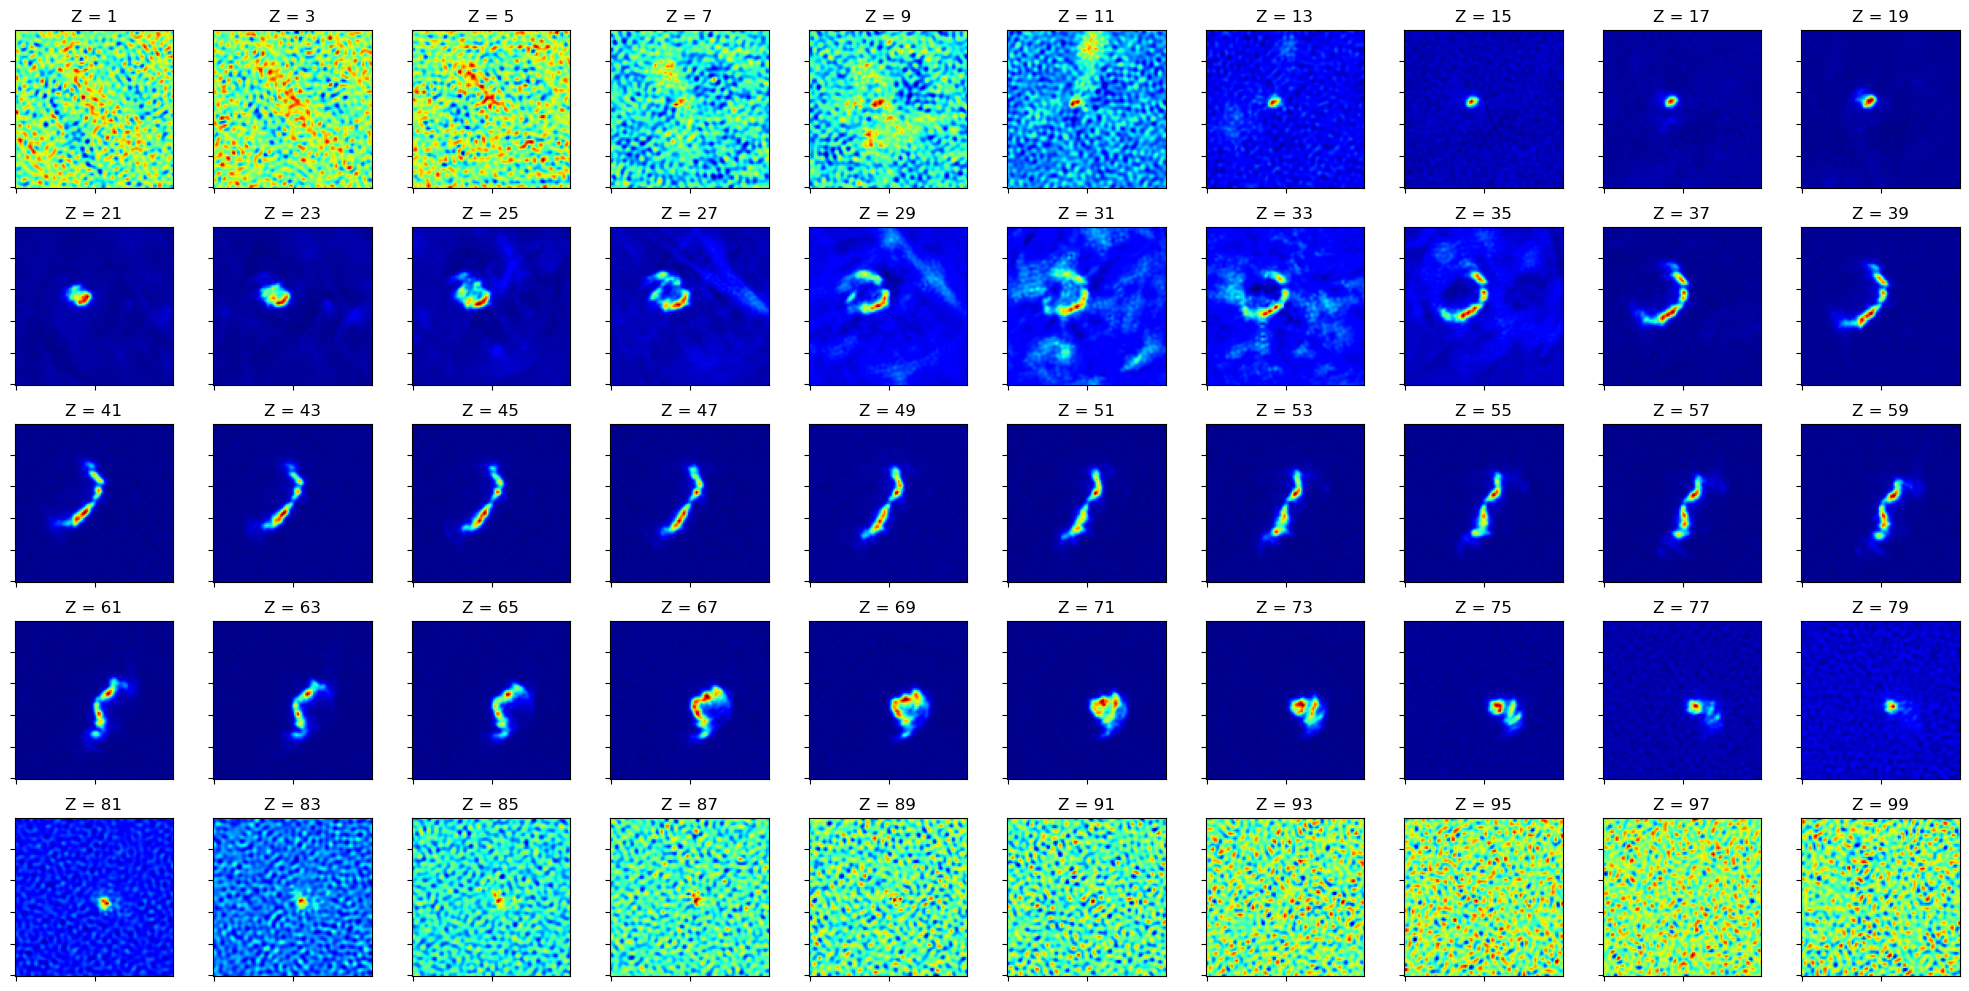

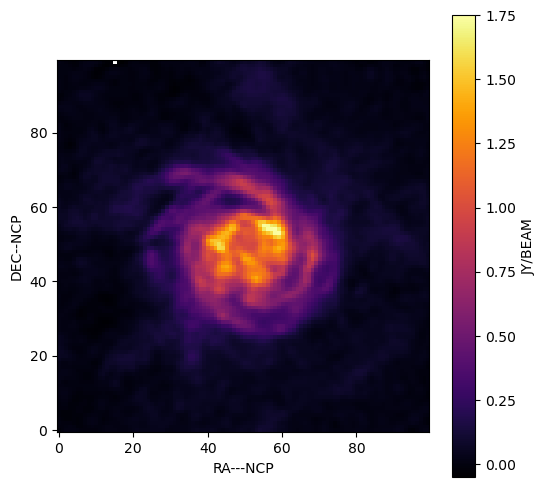

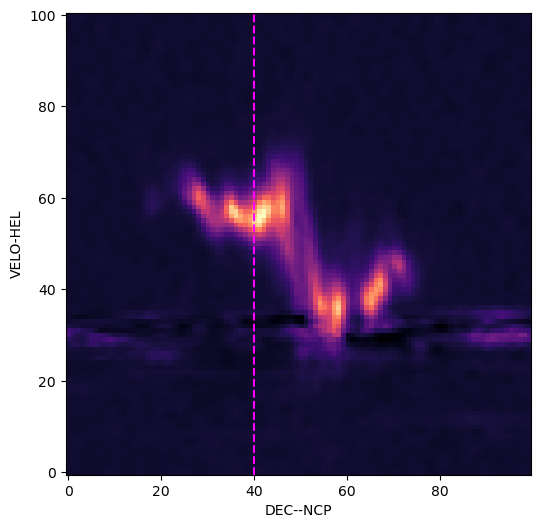

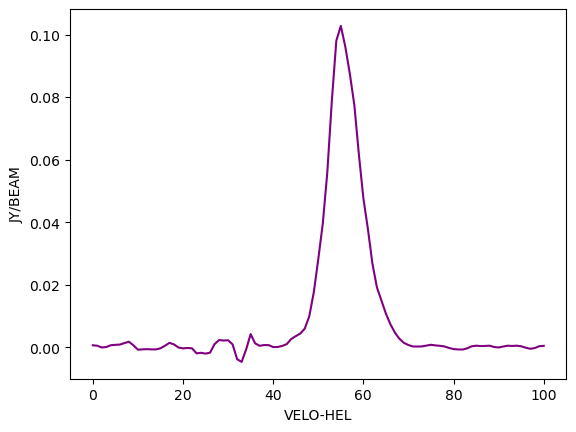

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

#opening the fits file and getting its data
hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data

#creating a range to later use it to take slices from our data
indices = list(range(1, 101, 2))  # 50 channels

#setting up the figure of 5 rows and 10 cplumns
fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(20, 10))

#flattening to work with it easier
axes = axes.flatten()


for ax, i in zip(axes, indices):
    #showing every other slice
    ax.imshow(data[i], origin='lower', cmap = 'jet')

    #deleting the ticklabels so the total figure is easier to look at
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    #setting a title for each individual image
    ax.set_title(f"Z = {i}")

#ensuring they're plotted nicely together
plt.tight_layout()
plt.show()


header = hdulist[0].header

#creating a range of all the images with the least amount of background noise
rangechannels = range(17, 79)

#creating the HI map using the range
HI_map = np.sum(data[rangechannels, :, :], axis=0)

#creating a figure to show the combined slices
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(HI_map, origin='lower', cmap='inferno')

#setting the axis labels
ax.set_xlabel(header['CTYPE1'])
ax.set_ylabel(header['CTYPE2'])

#adding a colorbar with a label
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(header['BUNIT'])

#show the plot
plt.show()


#fixing RA so we are working with only 2 variables and thus a 2D slice of the data
PV_map = data[:, :, 50]

#plotting the 2D slice as an image
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(PV_map, origin='lower', aspect='auto', cmap='magma')

#making a vertical line at Dec. with index 40
ax.axvline(x=40, color='magenta', linestyle='--')

#adding labels to the image
ax.set_xlabel(header['CTYPE2'])  
ax.set_ylabel(header['CTYPE3'])  

#showing the plot
plt.show()


#taking a slice with all the different velocities and a set RA and dec
spectrum = data[:, 40, 50]

#setting up the figure and plotting the intensity against the velocity
fig, ax = plt.subplots()
ax.plot(spectrum, color='purple')

#setting the labels
ax.set_xlabel(header['CTYPE3'])
ax.set_ylabel(header['BUNIT'])

#showing the plot
plt.show()

Question 6.8

                 ObjID          u          g          r          i          z
0  1237667429572346493  22.133240  22.190250  21.788059  21.355808  21.630119
1  1237665225699688707  21.623161  21.394985  20.979010  20.807341  21.209600
2  1237661849859391812  21.970703  21.247322  20.650488  20.399561  20.187206
3  1237655464310014355  21.850883  21.075569  20.600910  20.281101  20.171160
4  1237668332564316684  22.198875  21.121441  20.892130  20.848957  20.391762
5  1237661066014883916  22.019781  22.288691  21.737526  21.400118  21.716976
6  1237657772324159767  19.667578  18.601091  18.133766  17.896601  17.683422
7  1237650795142447568  21.675821  21.246296  20.862551  20.627028  20.648396
8  1237660634388627953  22.245190  21.974373  21.485096  21.381182  21.068920
9  1237667782815187920  22.373613  21.599819  21.180758  20.842199  21.134071


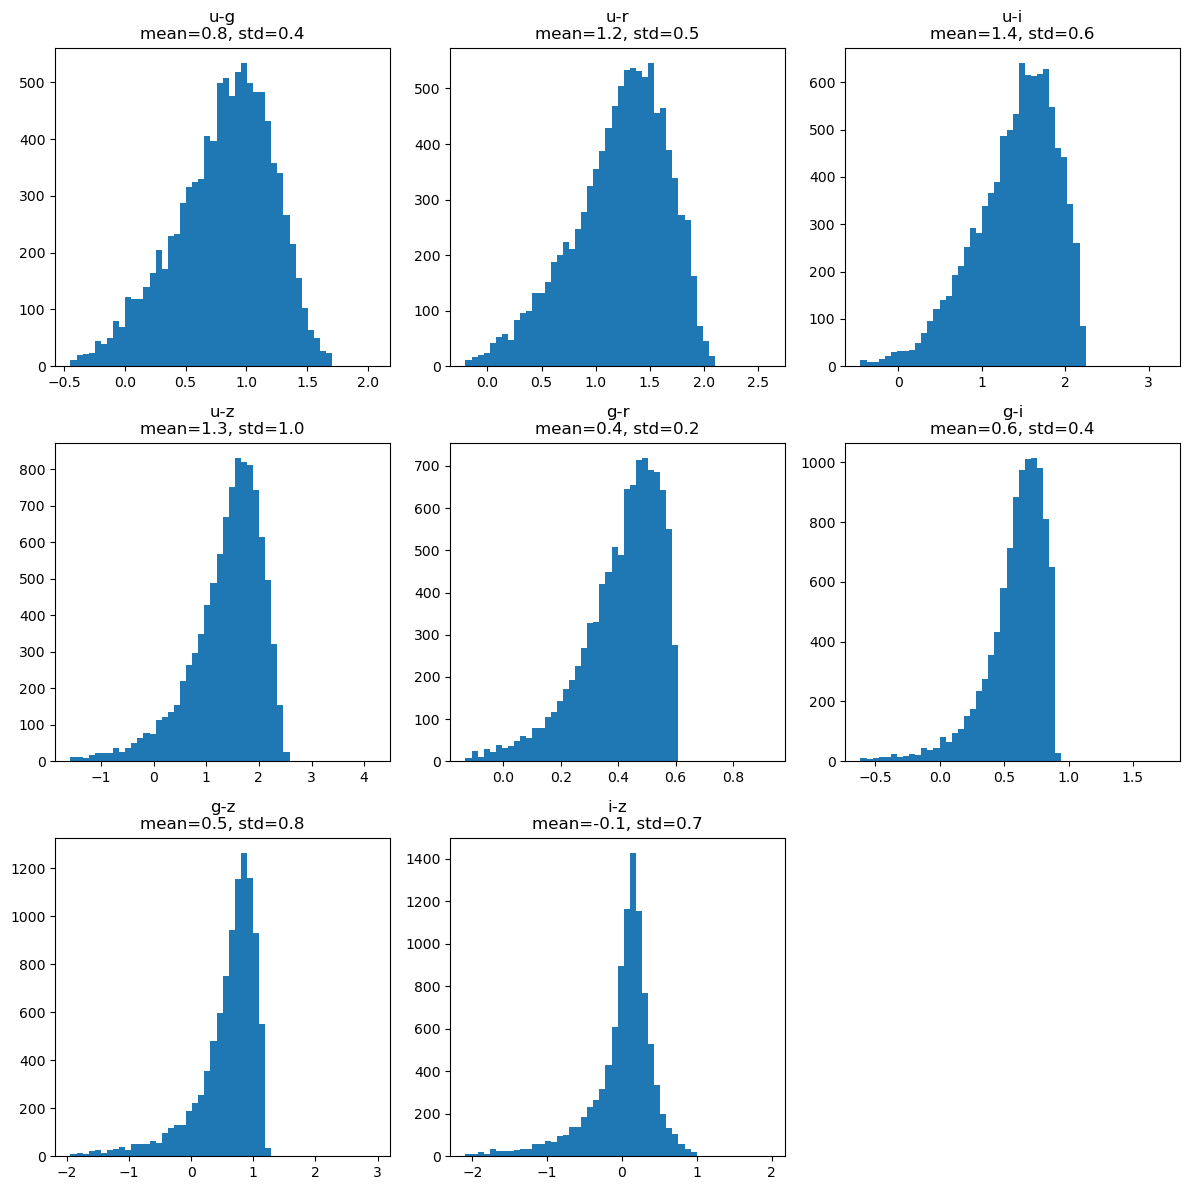

In [35]:
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt

hdul = fits.open('SDSS_DR17_galaxies.fits')
data = hdul[1].data

df = pd.DataFrame(data)

posdf = df[(df >= 0).all(axis=1)]
print(posdf[:10])

ug = posdf["u"] - posdf["g"]
ur = posdf["u"] - posdf["r"]
ui = posdf["u"] - posdf["i"]
uz = posdf["u"] - posdf["z"]
gr = posdf["g"] - posdf["r"]
gi = posdf["g"] - posdf["i"]
gz = posdf["g"] - posdf["z"]
iz = posdf["i"] - posdf["z"]

colors = [ug, ur, ui, uz, gr, gi, gz, iz]
color_names = ["u-g", "u-r", "u-i", "u-z", "g-r", "g-i", "g-z", "i-z"]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
axes = axes.flatten()

for ax, color, name in zip(axes, colors, color_names):
    mean = color.mean()
    std = color.std()
    ax.hist(color, bins=50, range=(mean-3*std, mean+3*std))
    ax.set_title(f"{name}\nmean={mean:.1f}, std={std:.1f}")

axes[-1].axis('off')

plt.tight_layout()
plt.show()

                 ObjID          u          g          r          i          z
0  1237667429572346493  22.133240  22.190250  21.788059  21.355808  21.630119
1  1237665225699688707  21.623161  21.394985  20.979010  20.807341  21.209600
2  1237661849859391812  21.970703  21.247322  20.650488  20.399561  20.187206
3  1237655464310014355  21.850883  21.075569  20.600910  20.281101  20.171160
4  1237668332564316684  22.198875  21.121441  20.892130  20.848957  20.391762
5  1237661066014883916  22.019781  22.288691  21.737526  21.400118  21.716976
6  1237657772324159767  19.667578  18.601091  18.133766  17.896601  17.683422
7  1237650795142447568  21.675821  21.246296  20.862551  20.627028  20.648396
8  1237660634388627953  22.245190  21.974373  21.485096  21.381182  21.068920
9  1237667782815187920  22.373613  21.599819  21.180758  20.842199  21.134071
u-g    0.804608
u-r    1.202665
u-i    1.369931
u-z    1.311232
g-r    0.398056
g-i    0.565322
g-z    0.506624
r-i    0.167266
r-z    0.10856

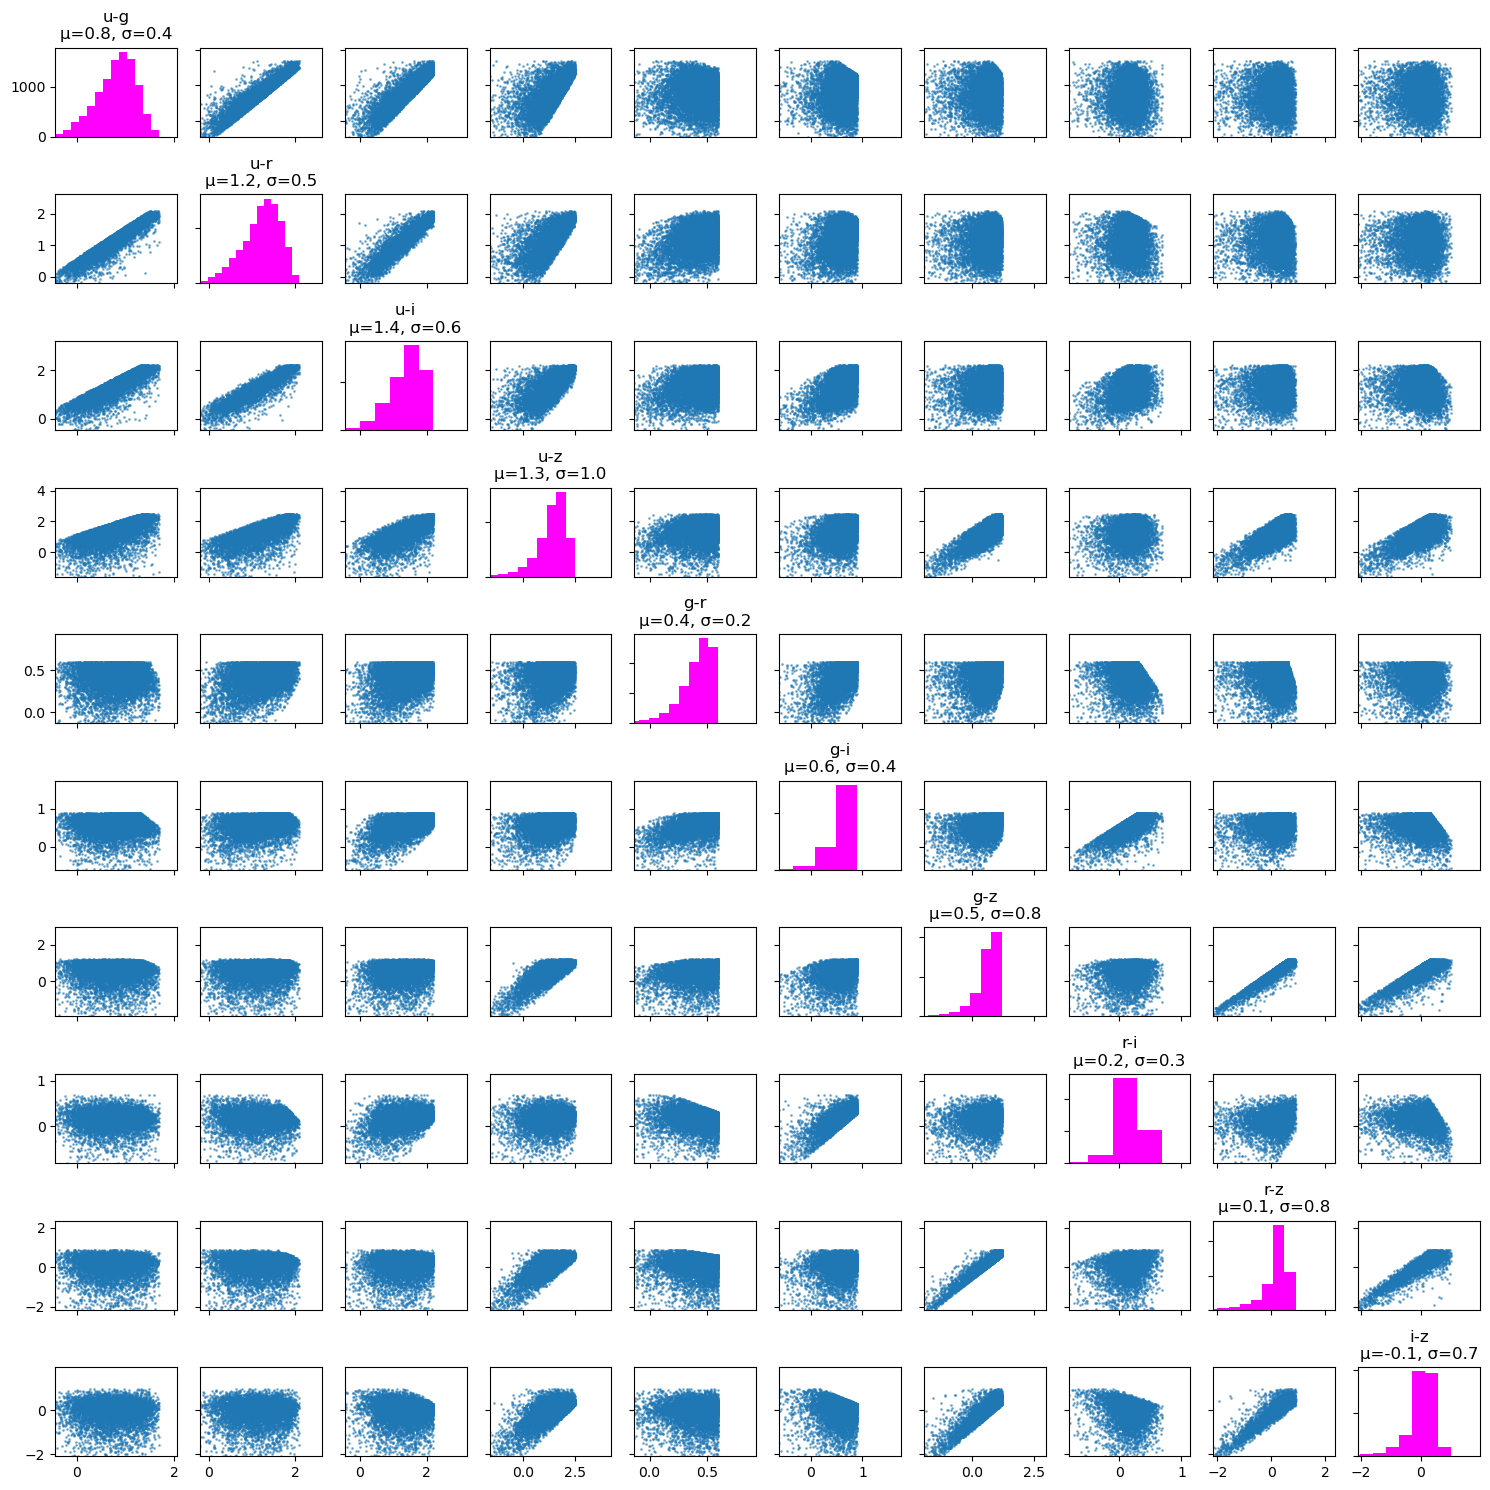

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pandas as pd

hdulist = fits.open("SDSS_DR17_galaxies.fits")
header = hdulist[0].header
data = hdulist[1].data
gal = pd.DataFrame(data)

pos = gal[(gal >= 0).all(axis=1)]
print(pos[:10])

colours = {
    "u-g": pos['u'] - pos['g'],
    "u-r": pos['u'] - pos['r'],
    "u-i": pos['u'] - pos['i'],
    "u-z": pos['u'] - pos['z'],
    "g-r": pos['g'] - pos['r'],
    "g-i": pos['g'] - pos['i'],
    "g-z": pos['g'] - pos['z'],
    "r-i": pos['r'] - pos['i'],
    "r-z": pos['r'] - pos['z'],
    "i-z": pos['i'] - pos['z'],
}

col_df = pd.DataFrame(colours)
means = col_df.mean()
stds = col_df.std()

print(means)
print(stds)

import matplotlib.pyplot as plt

cols = col_df.columns
n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(15, 15))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
       
        if i == j:
            # Histogram
            data = col_df[cols[i]]
            mean = means[cols[i]]
            std = stds[cols[i]]
           
            ax.hist(data, bins=30, color='magenta')
           
            # Set limits within 3 sigma
            ax.set_xlim(mean - 3*std, mean + 3*std)
           
            # Title with mean and std (1 decimal place)
            ax.set_title(f"{cols[i]}\nμ={mean:.1f}, σ={std:.1f}")
       
        else:
            # Scatter plot
            x = col_df[cols[j]]
            y = col_df[cols[i]]
           
            ax.scatter(x, y, s=1, alpha=0.5)
           
            # Apply 3-sigma limits
            ax.set_xlim(means[cols[j]] - 3*stds[cols[j]],
                        means[cols[j]] + 3*stds[cols[j]])
           
            ax.set_ylim(means[cols[i]] - 3*stds[cols[i]],
                        means[cols[i]] + 3*stds[cols[i]])
       
        # Clean up labels
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

Question 6.11

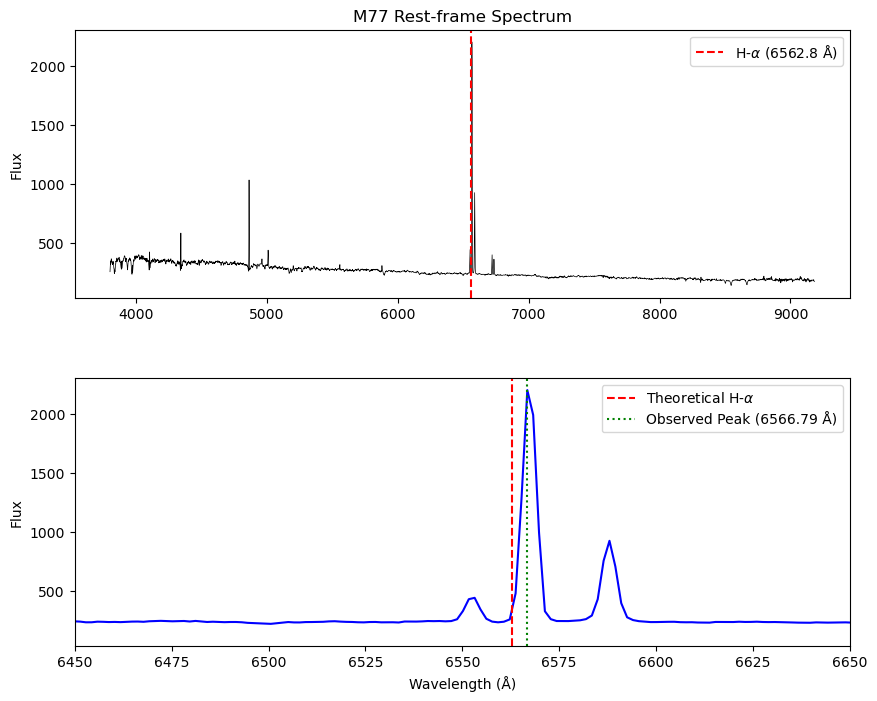

Peak wavelength found at: 6566.79 Å
Velocity offset: 182.05 km/s


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from astroquery.sdss import SDSS
from astropy import coordinates as coords

# 1. Setup Coordinates
ra, dec = 40.6696, -0.0133
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

# 2. Retrieve Data
xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
if xid is None:
    print("No spectra found in this region.")
else:
    sp = SDSS.get_spectra(matches=xid)
    # The data is in the second HDU (index 1) of the first object in the list
    data = sp[0][1].data
    flux = data['flux']
    # Convert log-wavelength to linear Angstroms
    wavelength_obs = 10**data['loglam']

    # 3. Correct for Redshift (Rest-frame)
    z = 0.0038
    wavelength_rest = wavelength_obs / (1 + z)

    # 4. Plotting (Object-Oriented)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
    plt.subplots_adjust(hspace=0.3)

    # Constants
    ha_rest = 6562.8  # H-alpha rest wavelength in Angstroms

    # Top Plot: Full Rest-frame Spectrum
    ax1.plot(wavelength_rest, flux, color='black', lw=0.5)
    ax1.axvline(ha_rest, color='red', linestyle='--', label=r'H-$\alpha$ (6562.8 Å)')
    ax1.set_title("M77 Rest-frame Spectrum")
    ax1.set_ylabel("Flux")
    ax1.legend()

    # Bottom Plot: Zoom-in (6450 - 6650 Å)
    ax2.plot(wavelength_rest, flux, color='blue')
    ax2.set_xlim(6450, 6650)
    
    # Identify the actual peak near H-alpha in the observed data
    mask = (wavelength_rest > 6500) & (wavelength_rest < 6600)
    peak_wave = wavelength_rest[mask][np.argmax(flux[mask])]
    
    ax2.axvline(ha_rest, color='red', linestyle='--', label=r'Theoretical H-$\alpha$')
    ax2.axvline(peak_wave, color='green', linestyle=':', label=f'Observed Peak ({peak_wave:.2f} Å)')
    ax2.set_xlabel("Wavelength (Å)")
    ax2.set_ylabel("Flux")
    ax2.legend()

    plt.show()

    # 5. Velocity Calculation
    # Using Doppler formula: v = c * (delta_lambda / lambda_rest)
    c = 299792.458 # km/s
    delta_lambda = peak_wave - ha_rest
    velocity = c * (delta_lambda / ha_rest)
    print(f"Peak wavelength found at: {peak_wave:.2f} Å")
    print(f"Velocity offset: {velocity:.2f} km/s")